## FACTOR-BASED MONTE CARLO

### ROLLING VAR

In [383]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm
from IPython.display import Markdown
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import json

config = {
    "tickers": ['SAN.MC', 'UCG.MI','BNP.PA', 'INGA.AS', 'DBK.DE'],
    "weights": [0.3, 0.25, 0.2, 0.15, 0.1],
    "start": "2022-01-01",
    "end": "2026-02-28",
    "train_start_normal": "2024-01-15",
    "train_end_normal": "2025-01-31",
    "train_start_stress": "2022-01-03",
    "train_end_stress": "2023-01-15",
    "test_start": "2025-02-03",
    "test_end": "2026-02-20",
    "confidence":0.99,
    "risk_factors": ['^STOXX', 'EXV1.DE', 'IEAC.MI', 'IPRP.SW', 'IBGL.AS']
}

with open("portfolio_config.json", "w") as f:
    json.dump(config, f, indent=9)


import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

np.random.seed(42)

In [384]:
with open("portfolio_config.json", "r") as f:
    config = json.load(f)

tickers = config["tickers"]
weights = config["weights"]
start = config["start"]
end = config["end"]
train_start_normal = config["train_start_normal"]
train_end_normal = config["train_end_normal"]
train_start_stress = config["train_start_stress"]
train_end_stress = config["train_end_stress"]
test_start = config["test_start"]
test_end = config["test_end"]
confidence = config["confidence"]
risk_factor_proxies = config["risk_factors"]


In [385]:
risk_factor_proxies = {
    'Market': '^STOXX',     # STOXX Europe 600 as a broad market proxy
    'Financial': 'EXV1.DE',       # Financial sector risk
    'Credit': 'IEAC.MI',    # Credit risk factor
    'Property':   'IPRP.SW',      # Property rate factor
    'Interest': 'IBGL.AS',     # Interest rate factor
}

In [386]:
Factor_Tickers = list(risk_factor_proxies.values())
##tickers is the portfolio tickers, which is defined from the config and used for part 1 (portfolio1)
All_Tickers = tickers +Factor_Tickers

In [387]:
def get_price_data(tickers, start_date="2020-01-01", end_date="2026-02-28"):
    data = yf.download(tickers, start=start_date, end=end_date, auto_adjust = True, progress=False)['Close']
    return data

def calculate_log_returns(prices_df):
    return np.log(prices_df / prices_df.shift(1)).dropna()

In [388]:
Price_normal = get_price_data(All_Tickers, train_start_normal, train_end_normal)
Log_R_normal = calculate_log_returns(Price_normal)

In [389]:
##Linear Regression
Portfolio_R_normal = Log_R_normal[tickers]  
PortfolioReturn = Portfolio_R_normal @ weights #y

Factor_R = Log_R_normal[Factor_Tickers]  #x 

In [390]:
def RunOLSRegression(PortfolioReturn: pd.Series,
                     FactorReturns: pd.DataFrame) -> pd.DataFrame:
    df = pd.concat([PortfolioReturn, FactorReturns], axis=1).dropna() 

    X = sm.add_constant(FactorReturns)
    y = PortfolioReturn

    model = sm.OLS(y, X).fit()

    result_df = pd.DataFrame({
        'Factor': model.params.index,
        'Beta': model.params.values,
        'T-Stat': model.tvalues.values,
        'P-Value': model.pvalues.values
    })

    result_df = result_df[result_df['Factor'] != 'const']
    result_df['P-Value'] = result_df['P-Value'].round(4)
    result_df = result_df[['Factor', 'Beta', 'T-Stat', 'P-Value']]

    return result_df, model.params.drop("const")

In [391]:
def GetPortR_Square(PortfolioReturn: pd.DataFrame,
                    FactorReturns: pd.DataFrame) -> tuple[float, float]:

    X = sm.add_constant(FactorReturns)
    y = PortfolioReturn
    Model = sm.OLS(y, X).fit()
    return Model.rsquared.round(2), Model.rsquared_adj.round(2)

GetPortR_Square(PortfolioReturn, Factor_R)

(np.float64(0.87), np.float64(0.87))

In [392]:
regression_result = RunOLSRegression(PortfolioReturn, Factor_R)
print(regression_result)

(    Factor      Beta     T-Stat  P-Value
1   ^STOXX -0.136149  -1.800771   0.0730
2  EXV1.DE  1.232776  28.111175   0.0000
3  IEAC.MI -0.484092  -1.814217   0.0709
4  IPRP.SW  0.061980   2.069158   0.0396
5  IBGL.AS  0.043677   0.616159   0.5384, ^STOXX    -0.136149
EXV1.DE    1.232776
IEAC.MI   -0.484092
IPRP.SW    0.061980
IBGL.AS    0.043677
dtype: float64)


In [393]:
FactorR = Factor_R.drop(columns=["^STOXX","IBGL.AS"]) 

In [394]:
regression_result = RunOLSRegression(PortfolioReturn, FactorR)
print(regression_result)

(    Factor      Beta     T-Stat  P-Value
1  EXV1.DE  1.177042  36.694508   0.0000
2  IEAC.MI -0.446919  -2.825899   0.0051
3  IPRP.SW  0.045245   1.586624   0.1139, EXV1.DE    1.177042
IEAC.MI   -0.446919
IPRP.SW    0.045245
dtype: float64)


In [395]:
FactorR = Factor_R.drop(columns=["^STOXX","IBGL.AS","IPRP.SW"]) 

In [396]:
regression_result = RunOLSRegression(PortfolioReturn, FactorR)
print(regression_result)

(    Factor      Beta     T-Stat  P-Value
1  EXV1.DE  1.196299  40.169448   0.0000
2  IEAC.MI -0.339362  -2.367913   0.0186, EXV1.DE    1.196299
IEAC.MI   -0.339362
dtype: float64)


In [397]:
def CalculateVIF(FactorReturns: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate Variance Inflation Factor (VIF) for each factor.
    """
    vif_data = pd.DataFrame()
    vif_data["Factor"] = FactorReturns.columns
    vif_data["VIF"] = [variance_inflation_factor(FactorReturns.values, i)
                       for i in range(FactorReturns.shape[1])]
    return vif_data

vif_result = CalculateVIF(FactorR)
print(vif_result)

    Factor       VIF
0  EXV1.DE  1.013554
1  IEAC.MI  1.013554


In [398]:
model = sm.OLS(PortfolioReturn, sm.add_constant(FactorR)).fit()
PortfolioBeta = model.params.drop("const")
PortfolioBeta.index 

Index(['EXV1.DE', 'IEAC.MI'], dtype='object')

In [399]:
## Pls note: beta parameter need to include both beta and the tickers
def generate_rolling_VaR_series(
    factor_returns,
    beta,
    start_date=None,
    end_date=None,
    window=250,
    simulations=10000,
    confidence=0.99

):
    # Step 0: Preprocess
    factor_returns = factor_returns.copy()
    factor_returns.index = pd.to_datetime(factor_returns.index)
    all_dates = factor_returns.index

    # Step 1: Validate beta
    if not isinstance(beta, pd.Series):
        raise ValueError("beta must be a pandas Series with index = factor tickers.")

    factor_names = list(beta.index)

    # Step 2: Check all beta factors exist in factor_returns
    missing_factors = [f for f in factor_names if f not in factor_returns.columns]
    if missing_factors:
        raise ValueError(f"Missing factors in factor_returns: {missing_factors}")

    # Step 3: Subset and reorder factor_returns
    factor_returns = factor_returns[factor_names]
    beta_vector = beta.values.reshape(1, -1)  # shape: (1, F)

    # Step 4: Date handling
    if len(factor_returns) <= window:
        raise ValueError(f"Factor returns too short: need at least {window + 1} rows.")

    if start_date is None:
        start_loc = window
        start_date = all_dates[start_loc]
    else:
        start_date = pd.to_datetime(start_date)
        if start_date not in all_dates:
            raise ValueError(f"start_date {start_date.date()} not in factor_returns.")
        start_loc = all_dates.get_loc(start_date)
        if start_loc < window:
            raise ValueError(f"start_date too early — need {window} days of history.")

    if end_date is None:
        end_date = all_dates[-1]
    else:
        end_date = pd.to_datetime(end_date)
        if end_date not in all_dates:
            raise ValueError(f"end_date {end_date.date()} not in factor_returns.")
    end_loc = all_dates.get_loc(end_date)

    # Step 5: Rolling simulation
    rolling_VaR = []

    for i in range(start_loc, end_loc + 1):
        window_factors = factor_returns.iloc[i - window:i]
        cov_matrix = np.cov(window_factors.T)

        sim_factors = np.random.multivariate_normal(
            mean=np.zeros(len(beta)),
            cov=cov_matrix,
            size=simulations
        )  # shape: (simulations x F)

        sim_portfolio = sim_factors @ beta_vector.T  # shape: (simulations x 1)
        var_i = np.percentile(sim_portfolio, (1 - confidence) * 100)

        rolling_VaR.append((all_dates[i], var_i))
        

    return pd.Series([v[1] for v in rolling_VaR], index=[v[0] for v in rolling_VaR])


In [400]:
Price_Total_All = get_price_data(All_Tickers, start, end)
Log_Total_R = calculate_log_returns(Price_Total_All)

In [401]:
rolling_var = generate_rolling_VaR_series(Log_Total_R, PortfolioBeta,test_start, test_end)

In [402]:
print(abs(rolling_var.describe()))

count    252.000000
mean       0.037304
std        0.004288
min        0.042598
25%        0.039559
50%        0.039060
75%        0.038205
max        0.026212
dtype: float64


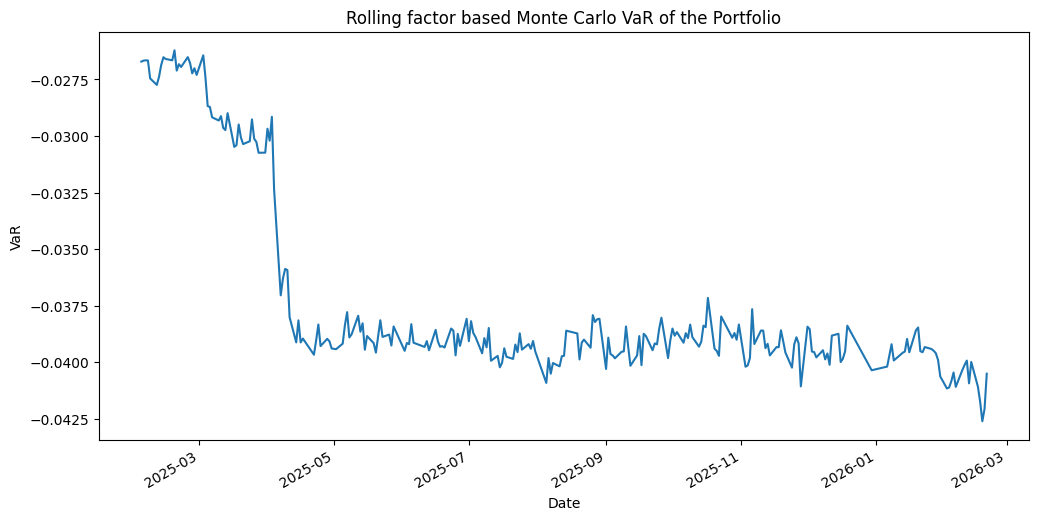

In [403]:
rolling_var.plot(title="Rolling factor based Monte Carlo VaR of the Portfolio", figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("VaR")
plt.show()

In [404]:
def backtest_VaR(real_returns, VaR):
    """
    Backtest VaR: support both static (single value) and rolling (Series) VaR.

    Parameters:
        real_returns (pd.Series): Actual portfolio returns.
        VaR (pd.Series): rolling VaR series.

    Returns:
        dict: violations, total, rate, zone
    """
    if not isinstance(real_returns, pd.Series):
        real_returns = pd.Series(real_returns)

    # Case 1: Rolling VaR (Series)
    if isinstance(VaR, pd.Series):
        real_returns, VaR = real_returns.align(VaR, join='inner')  # ensure alignment
        violations = real_returns < VaR

    num_violations = violations.sum()
    total_days = len(real_returns)
    violation_rate = num_violations / total_days

    # Basel traffic light zones
    if num_violations <= 4:
        zone = "Green"
    elif num_violations <= 9:
        zone = "Yellow"
    else:
        zone = "Red"

    return {
        "violations": int(num_violations),
        "total": total_days,
        "rate": violation_rate,
        "zone": zone
    }

In [405]:
test_start = config["test_start"]
test_end = config["test_end"]

test_prices = get_price_data(tickers, test_start, test_end)
test_returns = calculate_log_returns(test_prices)
test_P_returns = test_returns[tickers]  
test_P_return = test_P_returns @ weights

In [406]:
aligned_index = rolling_var.index.intersection(test_P_return.index)

rolling_var = rolling_var.loc[aligned_index]
test_P_return_aligned = test_P_return.loc[aligned_index]

x = test_P_return.loc[rolling_var.index].index
y = test_P_return.loc[rolling_var.index].values.astype("float64")
y2 = rolling_var.values
mask = y < y2

backtest_VaR(test_P_return , rolling_var)

{'violations': 5, 'total': 250, 'rate': np.float64(0.02), 'zone': 'Yellow'}

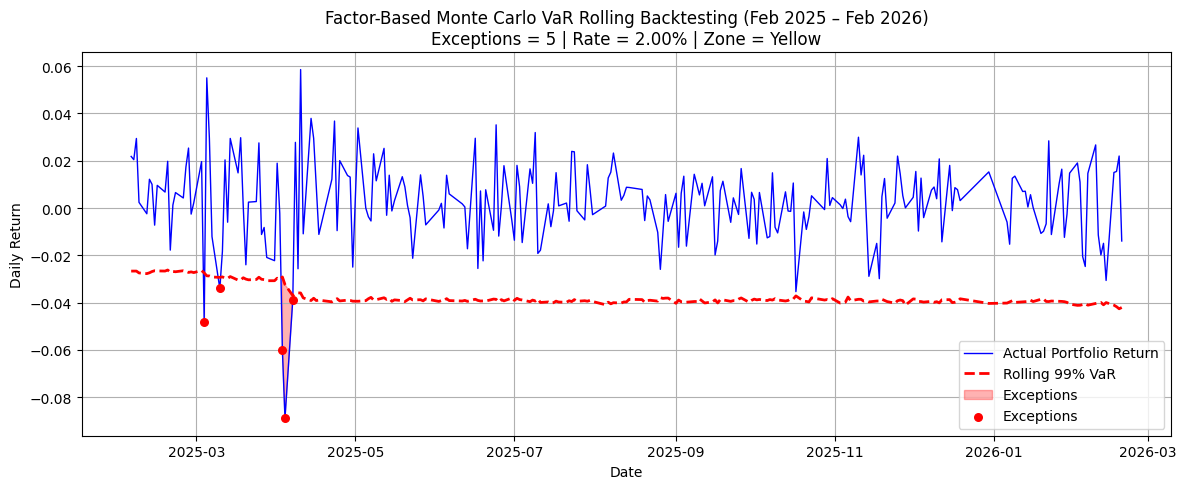

In [407]:
result = backtest_VaR(test_P_return, rolling_var)


plt.figure(figsize=(12, 5))
plt.plot(x, y, label="Actual Portfolio Return", color="blue", linewidth=1)
plt.plot(x, y2, color="red", linestyle="--", linewidth=2, label="Rolling 99% VaR")
plt.fill_between(x, y, y2, where=mask, color='red', alpha=0.3, label="Exceptions")
plt.scatter(x[mask], y[mask], color='red', s=30, label="Exceptions", zorder=5)
plt.title(f"Factor-Based Monte Carlo VaR Rolling Backtesting (Feb 2025 – Feb 2026)\n"
          f"Exceptions = {result['violations']} | "
          f"Rate = {result['rate']:.2%} | Zone = {result['zone']}")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Factor-Based Monte Carlo VaR Rolling Backtesting.png", dpi=300, bbox_inches='tight')
plt.show()

### Historical Stress Var (Hist SVaR)
According to (European Banking Authority, 2012), risk factors that used in the VaR model should also be used in SVaR. If for particular reasons, the risk factors are not used the same, similar risk factors can be used to test, as long as they are still relevant.
Upon performing the model, the author figured out that when changing the data input period, the linear relationships between risk factors and portfolio return might not be the same. 

Therefore, for Hist SVaR, risk factors will be tested to check the linear relationship again.

In [408]:
Price_stress = get_price_data(All_Tickers, train_start_stress, train_end_stress)
Log_R_stress = calculate_log_returns(Price_stress)

In [409]:
##Linear Regression
Portfolio_R_stress = Log_R_stress[tickers]  
PortfolioReturn_stress = Portfolio_R_stress @ weights #y

Factor_R_stress = Log_R_stress[Factor_Tickers]  #x 

In [410]:
def RunOLSRegression(PortfolioReturn_stress: pd.Series,
                     FactorReturns_1: pd.DataFrame) -> pd.DataFrame:
    df = pd.concat([PortfolioReturn_stress, FactorReturns_1], axis=1).dropna() 

    X_stress = sm.add_constant(FactorReturns_1)
    y_stress = PortfolioReturn_stress

    model_stress = sm.OLS(y_stress, X_stress).fit()

    result_df = pd.DataFrame({
        'Factor': model_stress.params.index,
        'Beta': model_stress.params.values,
        'T-Stat': model_stress.tvalues.values,
        'P-Value': model_stress.pvalues.values
    })

    result_df = result_df[result_df['Factor'] != 'const']
    result_df['P-Value'] = result_df['P-Value'].round(4)
    result_df = result_df[['Factor', 'Beta', 'T-Stat', 'P-Value']]

    return result_df

In [411]:
def GetPortR_Square(PortfolioReturn_stress: pd.DataFrame,
                    FactorReturns_1: pd.DataFrame) -> tuple[float, float]:

    X1 = sm.add_constant(FactorReturns_1)
    y1 = PortfolioReturn_stress
    Model_1 = sm.OLS(y1, X1).fit()
    return Model_1.rsquared.round(2), Model_1.rsquared_adj.round(2)

In [412]:
GetPortR_Square(PortfolioReturn_stress, Factor_R_stress)

(np.float64(0.92), np.float64(0.92))

In [413]:
regression_result_1 = RunOLSRegression(PortfolioReturn_stress, Factor_R_stress)
print(regression_result_1)

    Factor      Beta     T-Stat  P-Value
1   ^STOXX -0.261487  -3.859815   0.0001
2  EXV1.DE  1.302624  34.034725   0.0000
3  IEAC.MI  0.140840   0.931166   0.3527
4  IPRP.SW  0.044839   1.509631   0.1324
5  IBGL.AS -0.053316  -1.025068   0.3063


In [414]:
FactorR_stress = Factor_R_stress.drop(columns=["IEAC.MI","IPRP.SW","IBGL.AS"]) 

In [415]:
regression_result_2 = RunOLSRegression(PortfolioReturn_stress, FactorR_stress)
print(regression_result_2)

    Factor      Beta     T-Stat  P-Value
1   ^STOXX -0.195602  -3.540095   0.0005
2  EXV1.DE  1.303838  35.725014   0.0000


In [416]:
def CalculateVIF(FactorReturns_1: pd.DataFrame) -> pd.DataFrame:

    vif_data_1 = pd.DataFrame()
    vif_data_1["Factor"] = FactorReturns_1.columns
    vif_data_1["VIF"] = [variance_inflation_factor(FactorReturns_1.values, i)
                          for i in range(FactorReturns_1.shape[1])]
    return vif_data_1   

In [417]:
VIF_result_1 = CalculateVIF(FactorR_stress)
VIF_result_1

,Factor,VIF
0,^STOXX,2.707575
1,EXV1.DE,2.707575


In [418]:
def SimulateFactors(FactorReturns_1: pd.DataFrame, NSim: int = 10000):
    """
    Simulate multivariate normal factor returns based on historical covariance and mean.
    """
    assert isinstance(NSim, int), "NSim must be an integer"

    FactorCov = FactorReturns_1.cov().values
    FactorMean = FactorReturns_1.mean().values
    Simulated = np.random.multivariate_normal(mean=FactorMean, cov=FactorCov, size=NSim)

    return pd.DataFrame(Simulated, columns=FactorReturns_1.columns)

In [419]:
model_stress = sm.OLS(PortfolioReturn_stress, sm.add_constant(FactorR_stress)).fit()
PortfolioBeta_stress = model_stress.params.drop("const")

Simulated_Factor_DF_stress = SimulateFactors(FactorR_stress, 10000)[PortfolioBeta_stress.index]
SimulatedPortfolioReturn_stress = Simulated_Factor_DF_stress @ PortfolioBeta_stress.values
PortfolioBeta_stress.index

Index(['^STOXX', 'EXV1.DE'], dtype='object')

In [420]:
SimulatedPortfolioReturn_stress

0       0.024776
1      -0.022525
2       0.006361
3       0.007376
4      -0.005927
          ...   
9995   -0.038359
9996   -0.006785
9997   -0.011572
9998    0.000384
9999   -0.008677
Length: 10000, dtype: float64

In [429]:
SVaR = (np.percentile(SimulatedPortfolioReturn_stress, (1 - confidence) * 100))
print(f"1-day {int(confidence*100)}% Historical SVaR (fixed 2022 crisis window): {SVaR:.2%}")

1-day 99% Historical SVaR (fixed 2022 crisis window): -5.13%


In [422]:
SVaR_series = pd.Series(SVaR, index=test_P_return.index)
test_P_return_250 = test_P_return.iloc[-250:]
backtest_VaR(test_P_return_250, SVaR_series)

{'violations': 2, 'total': 250, 'rate': np.float64(0.008), 'zone': 'Green'}

### Hypothetical SVaR
According to (European Banking Authority, 2012), risk factors that used in the VaR model should also be used in SVaR. Since Hypothetical SVaR use the same data input period as normal VaR, the same risk factors used in Normal VaR will be used in this Hyp SVaR, which is financial risk (ticker 'EXV1.DE') and credit risk ('IEAC.MI')

In [423]:
print(Log_R_normal[['EXV1.DE', 'IEAC.MI']].describe())

Ticker     EXV1.DE     IEAC.MI
count   254.000000  254.000000
mean      0.001732    0.000237
std       0.009525    0.001979
min      -0.026472   -0.004780
25%      -0.003412   -0.001167
50%       0.002524    0.000297
75%       0.008166    0.001688
max       0.028285    0.006584


In [424]:
0.009569 * 4

0.038276

In [425]:
0.002002 * 4

0.008008

In [426]:
# ===================================================================
# EXTREME MEAN-SHOCK ONLY for Hypothetical SVaR
# (increase/decrease on EXV1.DE and IEAC.MI only)
# ===================================================================

# Choose extreme negative shocks (stress = large daily losses)
stress_shock = {
    "EXV1.DE": -0.038,   # ≈ -4.0 × daily std (very extreme loss)
    "IEAC.MI": -0.008    # ≈ -4.0 × daily std (very extreme loss)
}

# Simulate stressed factors (mean shifted, covariance unchanged)
FactorCov = Factor_R.cov().values
FactorMean = Factor_R.mean().values

# Build shock vector aligned with columns
shock_vector = np.array([stress_shock.get(col, 0) for col in Factor_R.columns])

# Stressed mean = original mean + extreme shock
stressed_mean = FactorMean + shock_vector

# Simulate 10,000 scenarios
Simulated_Factor_DF_stress_hyp = pd.DataFrame(
    np.random.multivariate_normal(
        mean=stressed_mean,
        cov=FactorCov,
        size=10000
    ),
    columns=Factor_R.columns
)

# Map to portfolio using your existing betas (only the factors you use)
SimulatedPortfolioReturn_hyp = Simulated_Factor_DF_stress_hyp[PortfolioBeta.index] @ PortfolioBeta.values

# Hypothetical SVaR (positive loss)
SVaR_hypo = (np.percentile(SimulatedPortfolioReturn_hyp, (1 - confidence) * 100))

print(f"Hypothetical SVaR (extreme mean shock only): {SVaR_hypo:.2%}")
 

Hypothetical SVaR (extreme mean shock only): -6.67%


In [427]:
SVaR_hypo_series = pd.Series(SVaR_hypo, index=test_P_return.index)
test_P_return_250 = test_P_return.iloc[-250:]
backtest_VaR(test_P_return_250, SVaR_hypo_series)

{'violations': 1, 'total': 250, 'rate': np.float64(0.004), 'zone': 'Green'}

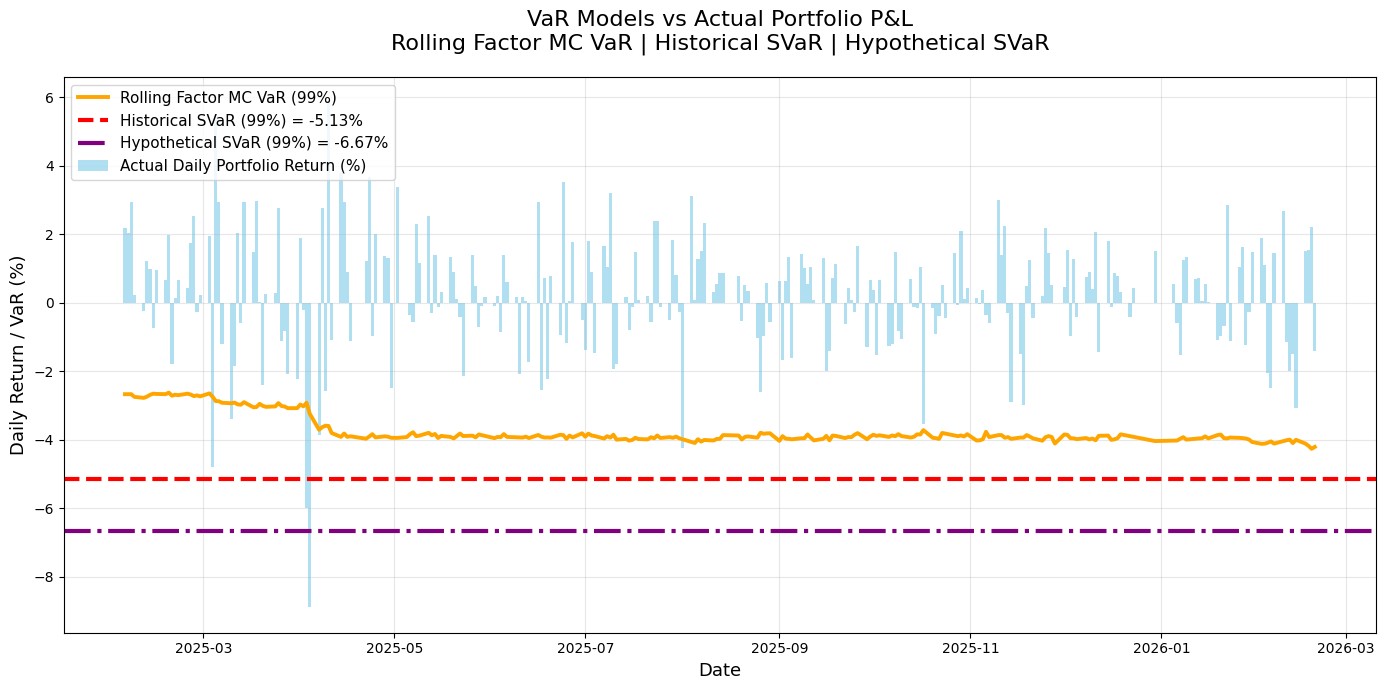


=== VaR MODEL COMPARISON TABLE ===
                   Model  Min (%)  Max (%)  Mean (%)  Std (%)  \
0  Rolling Factor MC VaR   -4.260   -2.621    -3.733    0.425   
1        Historical SVaR   -5.134   -5.134    -5.134    0.000   
2      Hypothetical SVaR   -6.672   -6.672    -6.672    0.000   

  Hist SVaR / rolling VaR ratio  Hypo SVaR / rolling VaR ratio  
0                          1.38x                         1.79x  
1                                                               
2                                                               


In [428]:
# Actual daily P&L on test period
actual_port_return = test_P_return.loc[config["test_start"]:config["test_end"]]

# ===================================================================
# 2. Professional Comparison Plot
# ===================================================================
fig, ax = plt.subplots(figsize=(14, 7))

# Actual P&L (bars)
ax.bar(actual_port_return.index, actual_port_return * 100,
       color='skyblue', alpha=0.65, width=1, label='Actual Daily Portfolio Return (%)')

# Rolling Normal VaR (MC factor model)
ax.plot(rolling_var.index, rolling_var * 100,
        color='orange', linewidth=2.8, label='Rolling Factor MC VaR (99%)')

# Historical SVaR (horizontal dashed)
ax.axhline(y=SVaR * 100, color='red', linestyle='--', linewidth=3,
           label=f'Historical SVaR (99%) = {SVaR:.2%}')

# Hypothetical SVaR (horizontal dash-dot)
ax.axhline(y=SVaR_hypo * 100, color='purple', linestyle='-.', linewidth=3,
           label=f'Hypothetical SVaR (99%) = {SVaR_hypo:.2%}')

# Formatting
ax.set_title('VaR Models vs Actual Portfolio P&L\n'
             'Rolling Factor MC VaR | Historical SVaR | Hypothetical SVaR',
             fontsize=16, pad=20)
ax.set_ylabel('Daily Return / VaR (%)', fontsize=13)
ax.set_xlabel('Date', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='upper left')


plt.tight_layout()

# Save high-resolution figure for
plt.savefig("VaR_Comparison_Rolling_Historical_Hypothetical.png", dpi=400, bbox_inches='tight')
plt.show()

# ===================================================================
# 3. Summary Table
# ===================================================================
summary_table = pd.DataFrame({
    "Model": ["Rolling Factor MC VaR", "Historical SVaR", "Hypothetical SVaR"],
    "Min (%)":   [rolling_var.min()*100, SVaR*100, SVaR_hypo*100],
    "Max (%)":   [rolling_var.max()*100, SVaR*100, SVaR_hypo*100],
    "Mean (%)":  [rolling_var.mean()*100, SVaR*100, SVaR_hypo*100],
    "Std (%)":   [rolling_var.std()*100, 0.0, 0.0],
    "Hist SVaR / rolling VaR ratio ":    [f"{SVaR / rolling_var.mean():.2f}x", "", ""],
    "Hypo SVaR / rolling VaR ratio":    [f"{SVaR_hypo / rolling_var.mean():.2f}x", "", ""]
}).round(3)

print("\n=== VaR MODEL COMPARISON TABLE ===")
print(summary_table)